In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# UCI bike sharing dataset - hourly data
# Link: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
hourly_bike = pd.read_csv('../data/hour.csv', parse_dates=['dteday'])

# Data preprocessing
hourly_bike["hr"] = hourly_bike["hr"] + 1  # change hour from 0-23 to 1-24 for better visualization
hourly_bike["yr"] = hourly_bike["yr"].map({0: 2011, 1: 2012})  # map year to actual year
hourly_bike["season"] = hourly_bike["season"].map({1: 'winter', 2: 'spring', 3: 'summer', 4: 'fall'}).astype('category') # map season to season names
hourly_bike["weathersit"] = hourly_bike["weathersit"].map({1: 'clear/ few clouds', 2: 'misty', 3: 'light snow/rain', 4: 'heavy rain/snow'}).astype('category')  # map weather situation to names
hourly_bike = hourly_bike.drop(columns=['instant', 'dteday', 'casual', 'registered'])  # drop unnecessary columns
hourly_bike

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,winter,2011,1,1,0,6,0,clear/ few clouds,0.24,0.2879,0.81,0.0000,16
1,winter,2011,1,2,0,6,0,clear/ few clouds,0.22,0.2727,0.80,0.0000,40
2,winter,2011,1,3,0,6,0,clear/ few clouds,0.22,0.2727,0.80,0.0000,32
3,winter,2011,1,4,0,6,0,clear/ few clouds,0.24,0.2879,0.75,0.0000,13
4,winter,2011,1,5,0,6,0,clear/ few clouds,0.24,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,winter,2012,12,20,0,1,1,misty,0.26,0.2576,0.60,0.1642,119
17375,winter,2012,12,21,0,1,1,misty,0.26,0.2576,0.60,0.1642,89
17376,winter,2012,12,22,0,1,1,clear/ few clouds,0.26,0.2576,0.60,0.1642,90
17377,winter,2012,12,23,0,1,1,clear/ few clouds,0.26,0.2727,0.56,0.1343,61


In [21]:
# Data Exploration and Non-null counts
print(hourly_bike.info())
print(hourly_bike.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      17379 non-null  category
 1   yr          17379 non-null  int64   
 2   mnth        17379 non-null  int64   
 3   hr          17379 non-null  int64   
 4   holiday     17379 non-null  int64   
 5   weekday     17379 non-null  int64   
 6   workingday  17379 non-null  int64   
 7   weathersit  17379 non-null  category
 8   temp        17379 non-null  float64 
 9   atemp       17379 non-null  float64 
 10  hum         17379 non-null  float64 
 11  windspeed   17379 non-null  float64 
 12  cnt         17379 non-null  int64   
dtypes: category(2), float64(4), int64(7)
memory usage: 1.5 MB
None
                 yr          mnth            hr       holiday       weekday  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    2011.502561      6.537775  

C:\Users\Timothy\AppData\Local\Temp\ipykernel_25248\3308745051.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = hourly_bike.corr()


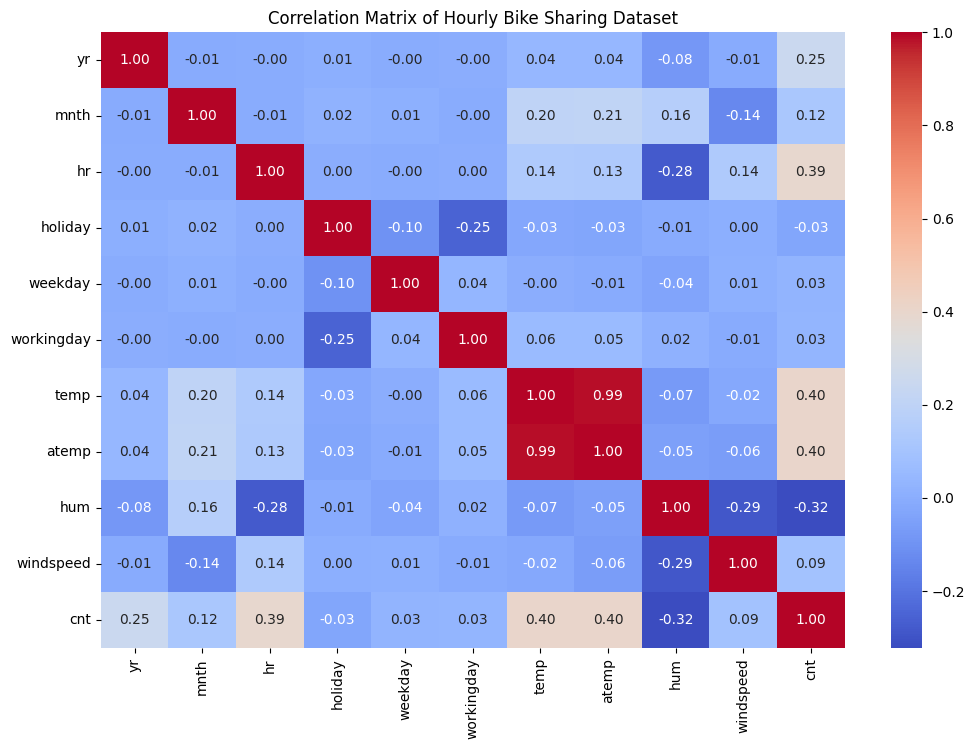

In [22]:
# Correlation matrix
corr_matrix = hourly_bike.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Hourly Bike Sharing Dataset')
plt.show()

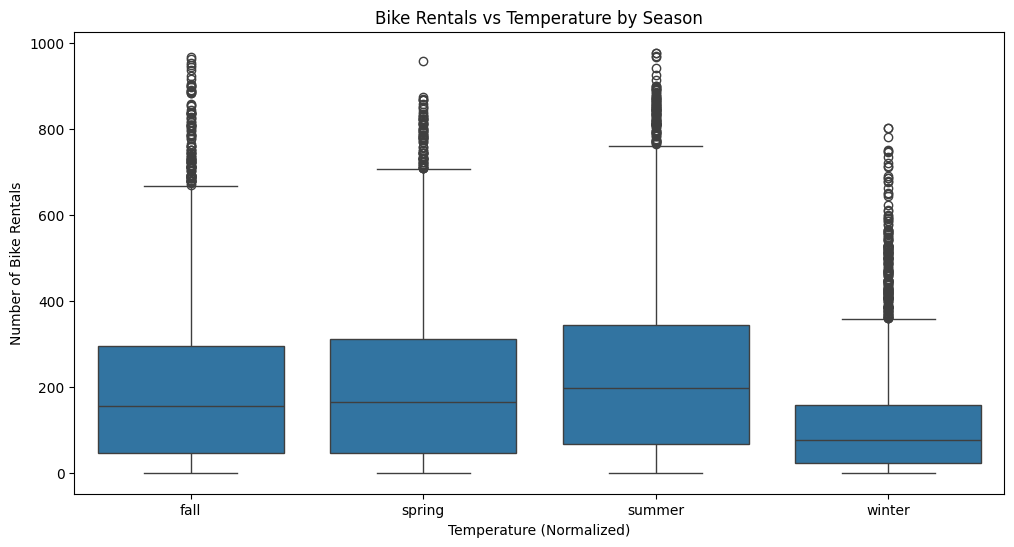

In [ ]:
# Boxplot for bike rentals vs temperature outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=hourly_bike, x='season', y='cnt')
plt.title('Bike Rentals vs Temperature by Season')
plt.xlabel('Temperature (Normalized)')
plt.ylabel('Number of Bike Rentals')
plt.show()

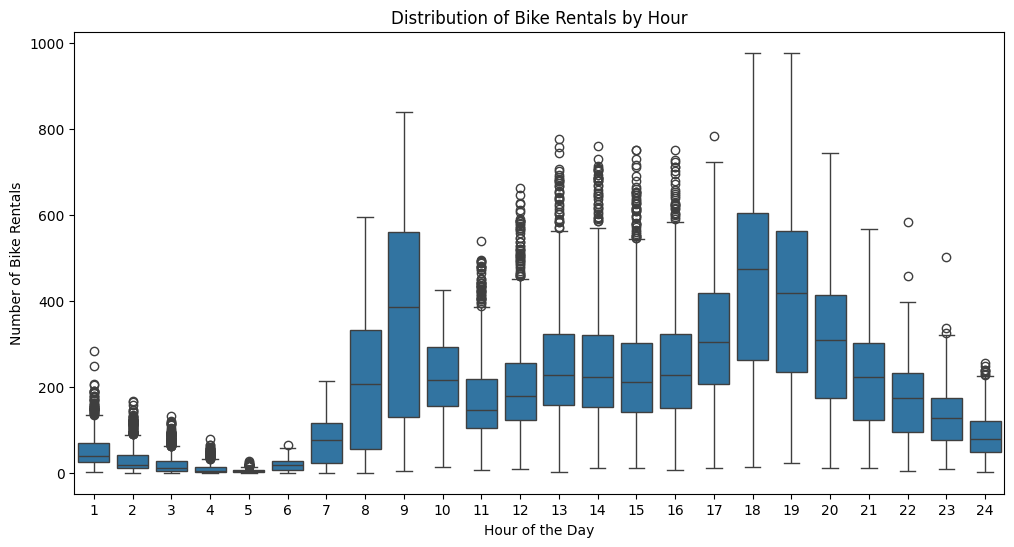

In [ ]:
# Target variable distribution by hour boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=hourly_bike, x='hr', y='cnt')
plt.title('Distribution of Bike Rentals by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Bike Rentals')
plt.show()

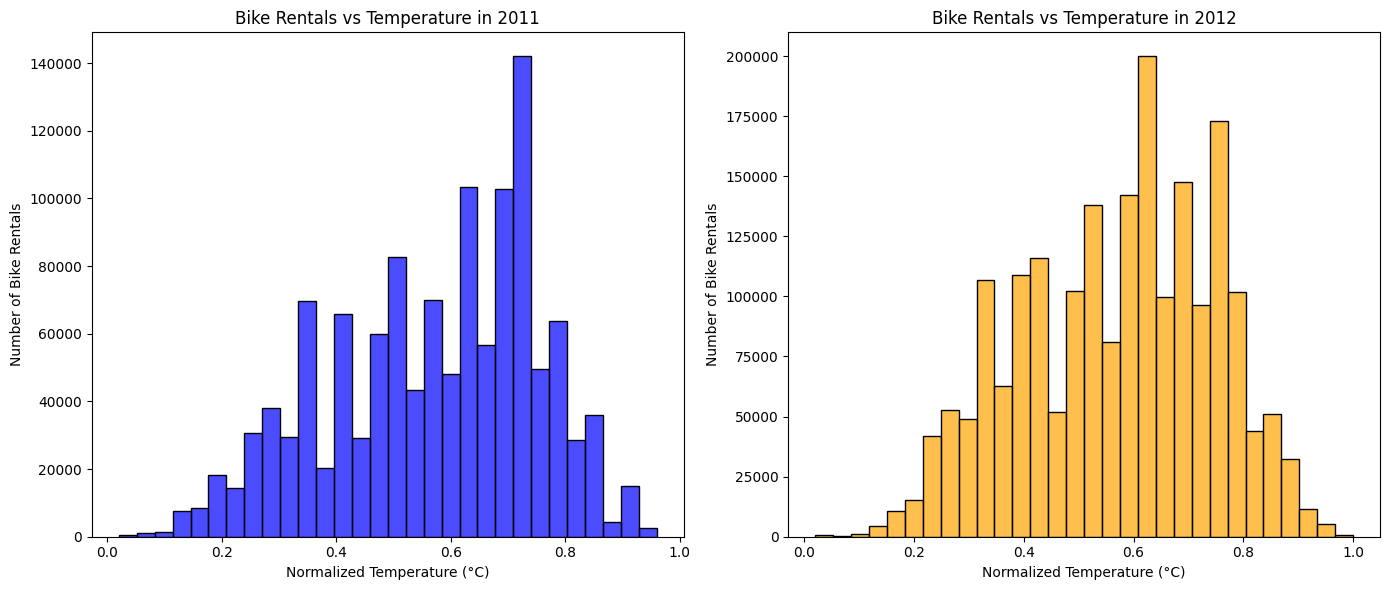

In [ ]:
# Target variable distribution by temperature and year
bike_hour_2011 = hourly_bike[hourly_bike['yr'] == 2011]
bike_hour_2012 = hourly_bike[hourly_bike['yr'] == 2012]

# two separate plots for two separate years
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(data=bike_hour_2011, x='temp', weights='cnt', bins=30, kde=False, color='blue', alpha=0.7)
plt.title('Bike Rentals vs Temperature in 2011')
plt.xlabel('Normalized Temperature (°C)')
plt.ylabel('Number of Bike Rentals')

plt.subplot(1, 2, 2)
sns.histplot(data=bike_hour_2012, x='temp', weights='cnt', bins=30, kde=False, color='orange', alpha=0.7)
plt.title('Bike Rentals vs Temperature in 2012')
plt.xlabel('Normalized Temperature (°C)')
plt.ylabel('Number of Bike Rentals')
plt.tight_layout()
plt.show()

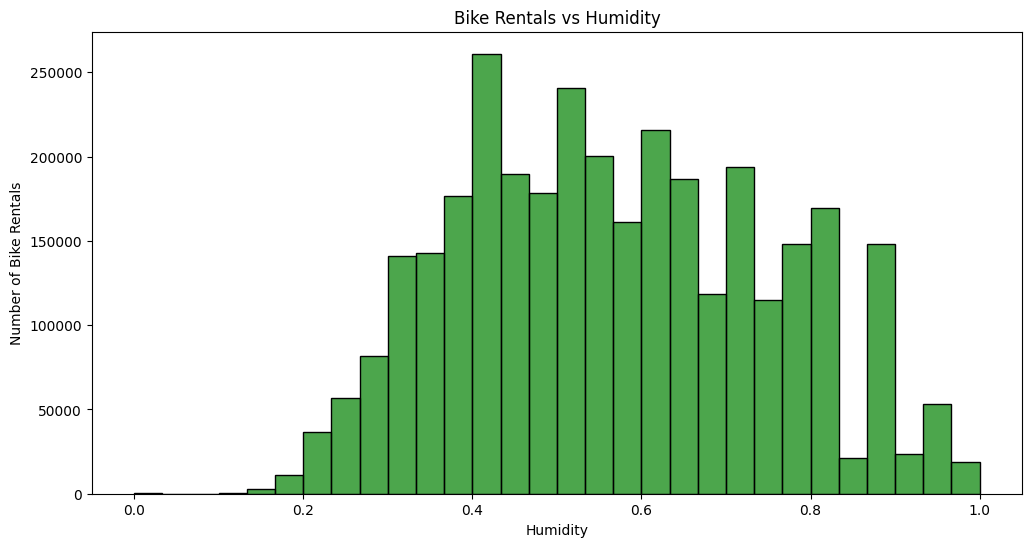

In [41]:
# humidity vs bike rentals
plt.figure(figsize=(12, 6))
sns.histplot(data=hourly_bike, x='hum', weights='cnt', bins=30, kde=False, color='green', alpha=0.7)
plt.title('Bike Rentals vs Humidity')
plt.xlabel('Humidity')
plt.ylabel('Number of Bike Rentals')
plt.show()